# nb04 · 热模型（温升与温度影响）

本篇目标：

1. 对比 **isothermal（等温）** vs **lumped（集总热）** 模型在高倍率放电下的温升。
2. 改变**环境温度**与**散热系数**，观察对温升 / 电压 / 容量的影响。
3. 定性认识电池的产热来源（欧姆热、反应热、可逆熵热）。

热模型通过 `options={"thermal": ...}` 开启：`"isothermal"`（恒温）/ `"lumped"`（单点集总）/ `"x-full"`（沿厚度分布）。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pybamm

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
print("PyBaMM 版本:", pybamm.__version__)

PyBaMM 版本: 26.6.1.1


## 1. isothermal vs lumped：高倍率放电温升

用 3C 放电放大产热效应。等温模型温度恒定，集总模型会出现温升。

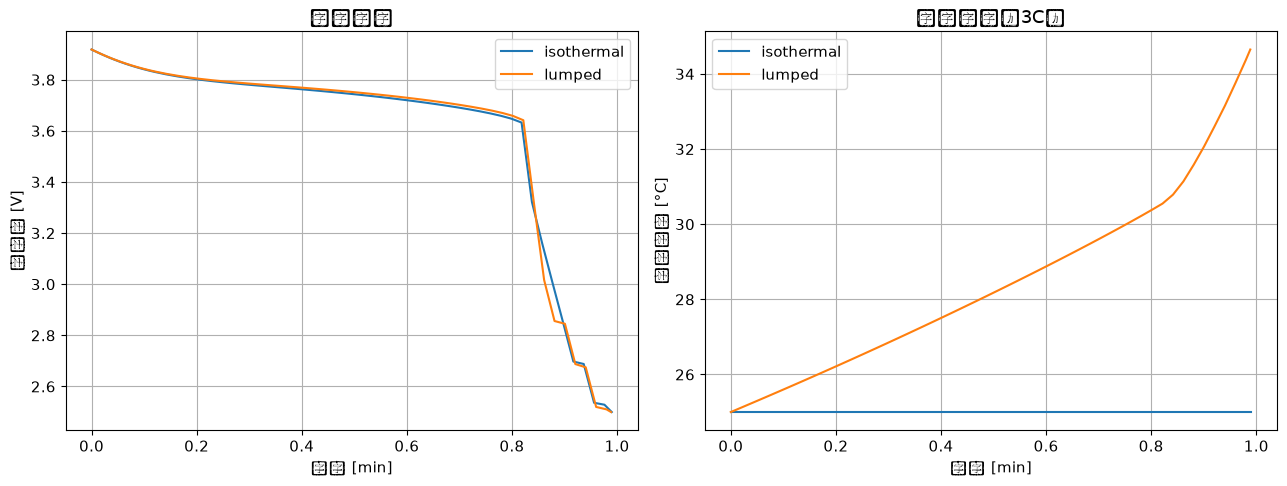

lumped 温升: 9.65 K
校验通过：lumped 模型温升 > 0。


In [2]:
experiment = pybamm.Experiment(["Discharge at 3C until 2.5 V"])
results = {}
for opt in ["isothermal", "lumped"]:
    model = pybamm.lithium_ion.SPMe(options={"thermal": opt})
    sim = pybamm.Simulation(model, parameter_values=pybamm.ParameterValues("Chen2020"),
                            experiment=experiment)
    results[opt] = sim.solve(initial_soc=1.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for opt, sol in results.items():
    t_min = sol["Time [s]"].entries / 60
    ax1.plot(t_min, sol["Terminal voltage [V]"].entries, label=opt)
    T_C = sol["Volume-averaged cell temperature [K]"].entries - 273.15
    ax2.plot(t_min, T_C, label=opt)
ax1.set_xlabel("时间 [min]"); ax1.set_ylabel("端电压 [V]"); ax1.set_title("电压曲线"); ax1.legend()
ax2.set_xlabel("时间 [min]"); ax2.set_ylabel("电池温度 [°C]"); ax2.set_title("温度曲线（3C）"); ax2.legend()
plt.tight_layout(); plt.show()

dT = results["lumped"]["Volume-averaged cell temperature [K]"].entries
print(f"lumped 温升: {dT.max()-dT.min():.2f} K")
assert dT.max() - dT.min() > 0, "集总热模型应出现温升"
print("校验通过：lumped 模型温升 > 0。")

## 2. 倍率越高，温升越大

产热近似随电流平方增长（欧姆项 I²R），因此高倍率下温升显著更大。

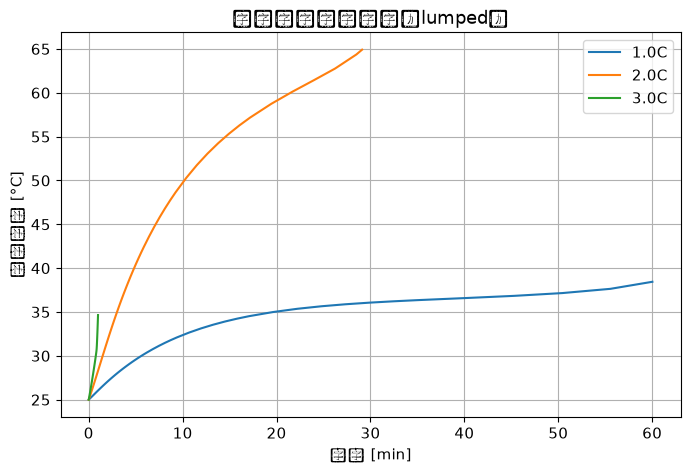

峰值温升 [K]: {1.0: np.float64(13.44), 2.0: np.float64(39.92), 3.0: np.float64(9.65)}


In [3]:
peak_rise = {}
for c in [1.0, 2.0, 3.0]:
    model = pybamm.lithium_ion.SPMe(options={"thermal": "lumped"})
    sim = pybamm.Simulation(model, parameter_values=pybamm.ParameterValues("Chen2020"),
                            experiment=pybamm.Experiment([f"Discharge at {c}C until 2.5 V"]))
    sol = sim.solve(initial_soc=1.0)
    T = sol["Volume-averaged cell temperature [K]"].entries
    peak_rise[c] = T.max() - T[0]
    plt.plot(sol["Time [s]"].entries / 60, T - 273.15, label=f"{c}C")
plt.xlabel("时间 [min]"); plt.ylabel("电池温度 [°C]")
plt.title("不同倍率下的温升（lumped）"); plt.legend(); plt.show()

print("峰值温升 [K]:", {c: round(v, 2) for c, v in peak_rise.items()})

## 3. 散热系数的影响

增大 `Total heat transfer coefficient [W.m-2.K-1]`（更强散热）会降低温升。

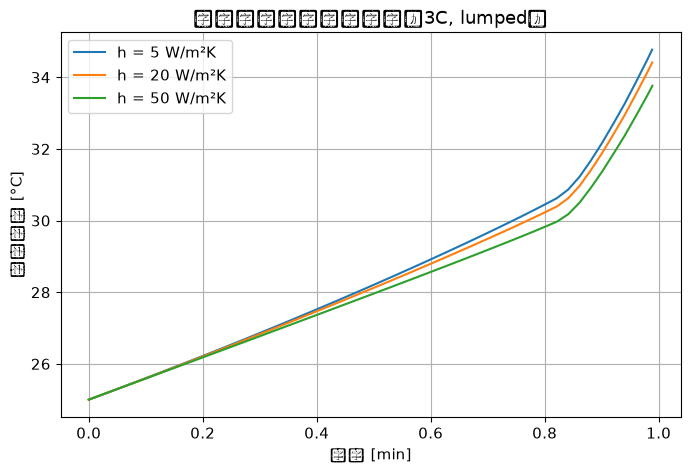

In [4]:
for h in [5.0, 20.0, 50.0]:
    param = pybamm.ParameterValues("Chen2020")
    param["Total heat transfer coefficient [W.m-2.K-1]"] = h
    model = pybamm.lithium_ion.SPMe(options={"thermal": "lumped"})
    sim = pybamm.Simulation(model, parameter_values=param,
                            experiment=pybamm.Experiment(["Discharge at 3C until 2.5 V"]))
    sol = sim.solve(initial_soc=1.0)
    T = sol["Volume-averaged cell temperature [K]"].entries - 273.15
    plt.plot(sol["Time [s]"].entries / 60, T, label=f"h = {h:g} W/m²K")
plt.xlabel("时间 [min]"); plt.ylabel("电池温度 [°C]")
plt.title("散热系数对温升的影响（3C, lumped）"); plt.legend(); plt.show()

## 4. 环境温度的影响

低温下电解液电导率与扩散变差，内阻增大，放电平台下降、可放出容量减少。

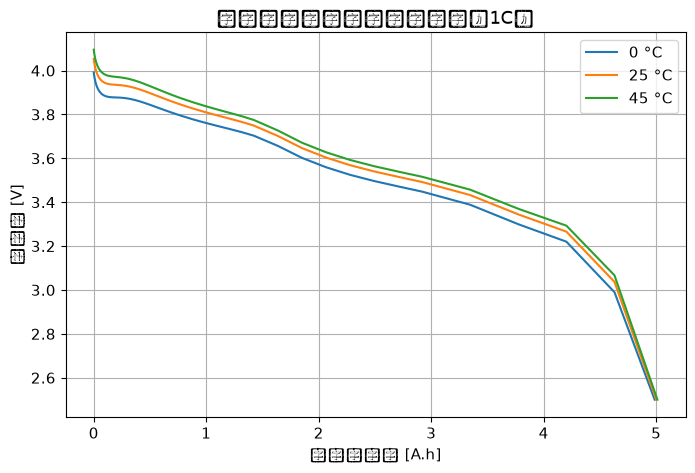

各环境温度放出容量 [A.h]: {0: np.float64(4.987), 25: np.float64(5.001), 45: np.float64(5.011)}


In [5]:
cap_vs_temp = {}
for T_amb_C in [0, 25, 45]:
    param = pybamm.ParameterValues("Chen2020")
    param["Ambient temperature [K]"] = 273.15 + T_amb_C
    param["Initial temperature [K]"] = 273.15 + T_amb_C
    model = pybamm.lithium_ion.SPMe(options={"thermal": "lumped"})
    sim = pybamm.Simulation(model, parameter_values=param,
                            experiment=pybamm.Experiment(["Discharge at 1C until 2.5 V"]))
    sol = sim.solve(initial_soc=1.0)
    cap = sol["Discharge capacity [A.h]"].entries
    cap_vs_temp[T_amb_C] = cap[-1]
    plt.plot(cap, sol["Terminal voltage [V]"].entries, label=f"{T_amb_C} °C")
plt.xlabel("已放出容量 [A.h]"); plt.ylabel("端电压 [V]")
plt.title("不同环境温度下的放电曲线（1C）"); plt.legend(); plt.show()

print("各环境温度放出容量 [A.h]:", {k: round(v, 3) for k, v in cap_vs_temp.items()})

## 小结

- `options={"thermal": "lumped"}` 即可在任一模型上叠加集总热模型，得到温升曲线。
- 温升随**倍率升高**而增大（产热 ~ I²R），随**散热系数增大**而减小。
- 产热来源：欧姆热（I²R）、反应（极化）热、可逆熵热；高倍率/低散热下温升是热失控的前兆——实际工程需配合散热设计。
- 下一篇 `nb05` 进入**老化与容量衰减**。